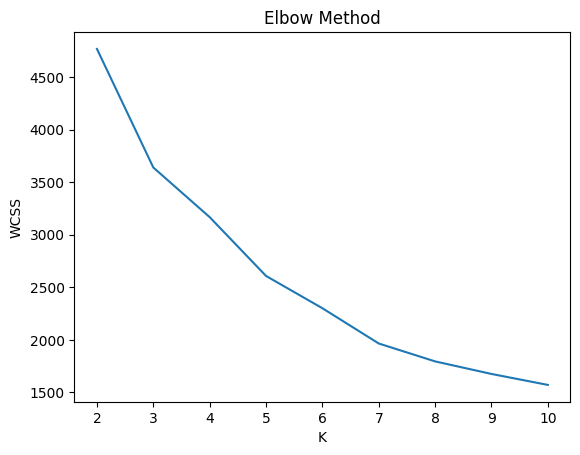

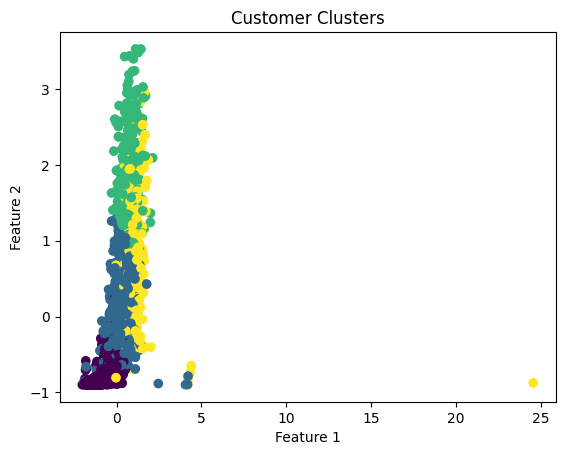

    Income  Cluster
0  58138.0        3
1  46344.0        0
2  71613.0        1
3  26646.0        0
4  58293.0        1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("marketing_campaign.csv")
X = df[['Income','MntWines','MntMeatProducts','NumWebPurchases']]
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss)
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Customer Clusters")
plt.show()
print(df[['Income','Cluster']].head())